In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
iris = pd.read_csv('data/iris.data', header=None) 

In [3]:
type(iris)

pandas.core.frame.DataFrame

In [4]:
X = iris.values[:, 0:4]
y = iris.values[:, 4]

In [5]:
X.shape, y.shape

((150, 4), (150,))

In [6]:
from sklearn.neighbors import KNeighborsClassifier

In [7]:
model = KNeighborsClassifier(n_neighbors=1)

In [8]:
from sklearn.model_selection import train_test_split as 훈련시험분리

In [9]:
X_train, X_test, y_train, y_test = 훈련시험분리(X, y)#, shuffle=True, test_size=0.25)

In [10]:
X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 4), (112, 4), (38, 4), (112,), (38,))

In [11]:
model.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


모델 평가

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [13]:
y_test_pred.shape

(38,)

In [14]:
훈련점수 = np.mean(y_train == y_train_pred)
시험점수 = np.mean(y_test == y_test_pred)

In [15]:
훈련점수, 시험점수

(np.float64(1.0), np.float64(0.9736842105263158))

# 지도학습 

In [16]:
from sklearn.datasets import load_breast_cancer

In [17]:
cancer = load_breast_cancer()

In [18]:
type(cancer)

sklearn.utils._bunch.Bunch

In [19]:
cancer.data.shape

(569, 30)

In [20]:
pd.DataFrame(cancer.data, columns=cancer.feature_names)[:5]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
np.unique(cancer.target)

array([0, 1])

In [22]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [23]:
cancer = pd.read_csv('data/cancer.csv')

In [24]:
cancer[:5]

,type,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
X_cancer = cancer.values[:, 1:]
y_cancer = cancer.values[:, 0]

In [26]:
X_cancer.shape, y_cancer.shape

((569, 30), (569,))

In [27]:
np.unique(y_cancer)

array(['benign', 'malignant'], dtype=object)

In [28]:
def 모델평가(model, X, y, **설정):
    X_train, X_test, y_train, y_test = 훈련시험분리(X, y, **설정)
    model.fit(X_train, y_train)
    훈련점수 = model.score(X_train, y_train)
    시험점수 = model.score(X_test, y_test)
    return 훈련점수, 시험점수

In [29]:
model = KNeighborsClassifier(n_neighbors=1)
모델평가(model, X_cancer, y_cancer, random_state=0)

(1.0, 0.916083916083916)

In [30]:
model = KNeighborsClassifier(n_neighbors=5)
모델평가(model, X_cancer, y_cancer, random_state=0)

(0.9413145539906104, 0.9370629370629371)

In [31]:
boston = pd.read_csv('data/boston.csv')

In [32]:
boston[:5]

,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [33]:
X_boston = boston.values[:, 1:]
y_boston = boston.values[:, 0]
X_boston.shape, y_boston.shape

((506, 13), (506,))

(array([ 21.,  55.,  82., 154.,  84.,  41.,  30.,   8.,  10.,  21.]),
 array([ 5. ,  9.5, 14. , 18.5, 23. , 27.5, 32. , 36.5, 41. , 45.5, 50. ]),
 <BarContainer object of 10 artists>)

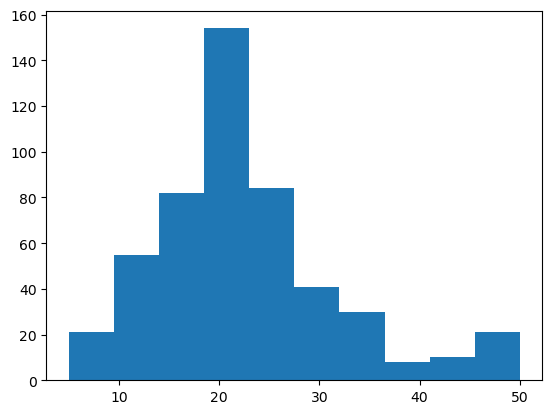

In [34]:
plt.hist(y_boston)

In [35]:
from sklearn.neighbors import KNeighborsRegressor

In [36]:
model = KNeighborsRegressor(n_neighbors=1)
모델평가(model, X_boston, y_boston)

(1.0, 0.42135950501694364)

모델 설정에 따른 성능 평가

In [37]:
훈련결과 = {}
for 이웃수 in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=이웃수)
    훈련점수, 시험점수 = 모델평가(model, X_cancer, y_cancer, stratify=y_cancer, random_state=2)
    훈련결과[이웃수] = {'train': 훈련점수, 'test': 시험점수}

In [38]:
훈련결과표 = pd.DataFrame(훈련결과).T

<Axes: >

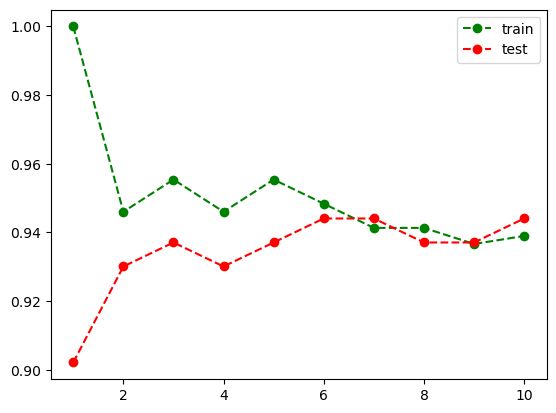

In [39]:
훈련결과표.plot(style={'train': 'go--', 'test': 'ro--'})

In [40]:
훈련결과 = {}
for 이웃수 in range(1, 11):
    model = KNeighborsRegressor(n_neighbors=이웃수)
    훈련점수, 시험점수 = 모델평가(model, X_boston, y_boston, random_state=0)
    훈련결과[이웃수] = {'train': 훈련점수, 'test': 시험점수}

In [41]:
훈련결과표 = pd.DataFrame(훈련결과).T

<Axes: >

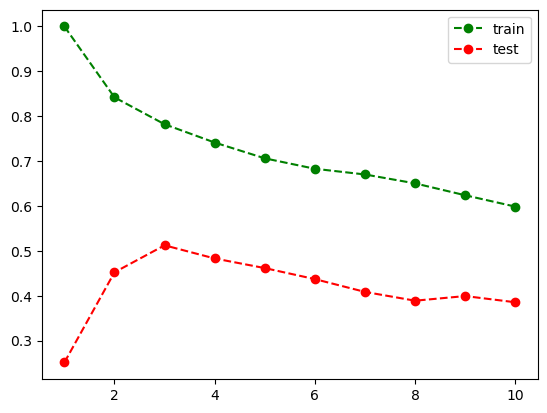

In [42]:
훈련결과표.plot(style={'train': 'go--', 'test': 'ro--'})

In [43]:
model

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
y_pred = model.predict(X_boston)

In [45]:
y_pred[:5]

array([24.53, 22.78, 25.5 , 24.26, 25.18])

In [46]:
from sklearn.metrics import r2_score

In [47]:
r2_score(y_boston, y_pred)

0.5469481959525154

# 선형 모델 

In [48]:
x = np.arange(-5, 5, 0.1)

In [49]:
잡음 = np.random.randn(len(x))
y = x + 잡음

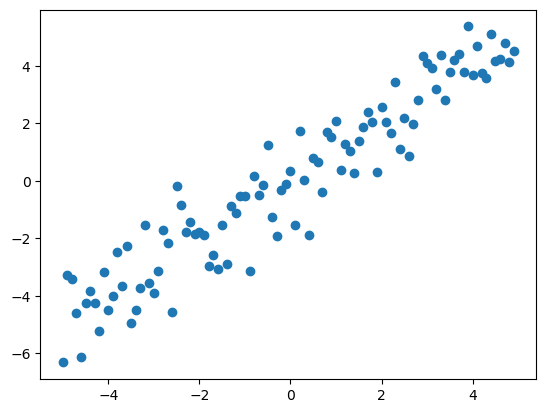

In [50]:
plt.scatter(x, y)

In [51]:
x.shape, y.shape

((100,), (100,))

In [52]:
X = x.reshape(-1, 1)
X.shape

(100, 1)

In [53]:
X_train, X_test, y_train, y_test = 훈련시험분리(X, y, shuffle=False)

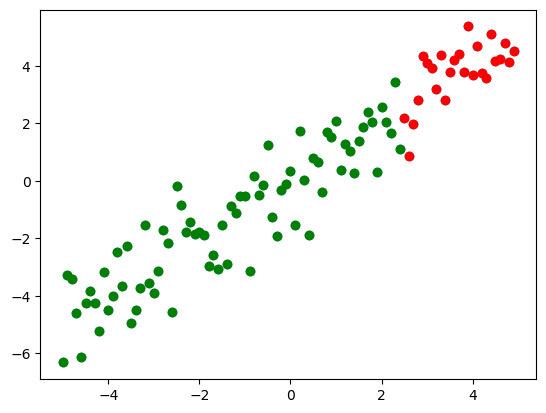

In [54]:
plt.scatter(x, y)
plt.scatter(X_train.flatten(), y_train, color='green')
plt.scatter(X_test.flatten(), y_test, color='red')

In [55]:
knn = KNeighborsRegressor().fit(X_train, y_train)

In [56]:
knn_pred = {}
knn_pred['train'] = knn.predict(X_train)
knn_pred['test'] = knn.predict(X_test)

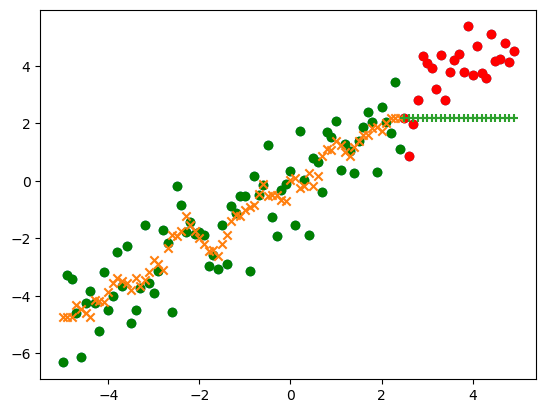

In [57]:
plt.scatter(x, y)
plt.scatter(X_train.flatten(), y_train, color='green')
plt.scatter(X_test.flatten(), y_test, color='red')
# 예측 결과
plt.scatter(X_train.flatten(), knn_pred['train'], marker='x')
plt.scatter(X_test.flatten(), knn_pred['test'], marker='+')

In [58]:
knn.score(X_train, y_train), knn.score(X_test, y_test)

(0.8113052756591329, -2.647858979849113)

In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
선형회귀 = LinearRegression().fit(X_train, y_train)

In [61]:
선형회귀_예측 = {}
선형회귀_예측['train'] = 선형회귀.predict(X_train)
선형회귀_예측['test'] = 선형회귀.predict(X_test)

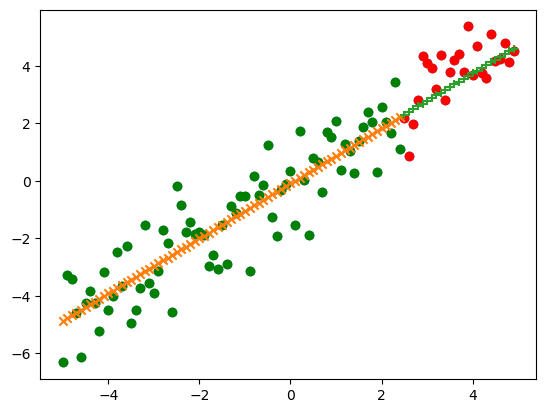

In [62]:
plt.scatter(x, y)
plt.scatter(X_train.flatten(), y_train, color='green')
plt.scatter(X_test.flatten(), y_test, color='red')
# 예측 결과
plt.scatter(X_train.flatten(), 선형회귀_예측['train'], marker='x')
plt.scatter(X_test.flatten(), 선형회귀_예측['test'], marker='+')

In [63]:
선형회귀.score(X_train, y_train), 선형회귀.score(X_test, y_test)

(0.80527028016312, 0.30422854206471417)

In [64]:
선형회귀.coef_

array([0.95653122])

In [65]:
선형회귀.intercept_

np.float64(-0.08456722998676636)

In [66]:
모델평가(KNeighborsRegressor(n_neighbors=5), X_boston, y_boston)

(0.7203550984834504, 0.44208601221373844)

In [67]:
모델평가(선형회귀, X_boston, y_boston)

(0.7570559039325816, 0.6647636747592677)

In [68]:
선형회귀

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


선형모델 최적화 개선

In [69]:
from sklearn.preprocessing import PolynomialFeatures

In [70]:
다항식_차원확장기 = PolynomialFeatures(degree=2)

In [71]:
XX_boston = 다항식_차원확장기.fit_transform(X_boston)

In [72]:
X_boston.shape, XX_boston.shape

((506, 13), (506, 105))

In [73]:
모델평가(선형회귀, X_boston, y_boston, random_state=0)

(0.769744837056394, 0.6353620786674616)

In [74]:
모델평가(선형회귀, XX_boston, y_boston, random_state=0)

(0.9523526436864239, 0.6057754893094713)